# Macro vs ETF Sensitivity Sandbox

Test how fixed-income ETFs move against Treasury yield changes and credit spread changes using ETF Terminal data.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from db.connection import get_engine
from stores.market import PriceStore
from stores.macro import MacroStore

In [3]:
DATA_BACKEND = "local"
APP_ENV = "uat"
START_DATE = "2024-01-01"
TICKERS = ["TLT", "IEF", "LQD", "HYG"]

In [4]:
engine = get_engine(data_backend=DATA_BACKEND, app_env=APP_ENV)
price_store = PriceStore(engine)
macro_store = MacroStore(engine)

In [5]:
price_histories = price_store.get_multi_ticker_price_history(TICKERS, start_date=START_DATE)
prices = pd.DataFrame({ticker: frame["adj_close"] for ticker, frame in price_histories.items()}).dropna()
etf_returns = np.log(prices).diff().dropna()
etf_returns.tail()

,HYG,IEF,LQD,TLT
date,,,,
2026-03-30,0.001143,0.007057,0.006391,0.013224
2026-03-31,0.009472,0.001783,0.006259,-0.001038
2026-04-01,-0.002391,-0.004200,-0.003032,-0.004973
2026-04-02,0.002391,0.002312,0.004224,0.006125
2026-04-06,0.001758,-0.002628,-0.001559,-0.001614


In [6]:
series_ids = ["DGS2", "DGS5", "DGS10", "DGS30", "BAMLC0A0CM", "BAMLH0A0HYM2"]
macro = macro_store.get_series_matrix(series_ids, start_date=START_DATE)
macro.tail()

,BAMLC0A0CM,BAMLH0A0HYM2,DGS10,DGS2,DGS30,DGS5
date,,,,,,
2026-03-30,0.93,3.46,4.35,3.82,4.91,3.97
2026-03-31,0.90,3.28,4.30,3.79,4.88,3.92
2026-04-01,0.87,3.16,4.33,3.81,4.91,3.97
2026-04-02,0.86,3.17,4.31,3.79,4.88,3.94
2026-04-03,0.86,3.13,4.35,3.84,4.91,3.99


In [7]:
rate_changes_bps = macro[["DGS2", "DGS5", "DGS10", "DGS30"]].diff() * 100.0
oas_changes_bps = macro[["BAMLC0A0CM", "BAMLH0A0HYM2"]].diff() * 100.0
factors = pd.concat([rate_changes_bps, oas_changes_bps], axis=1).dropna()
factors.tail()

,DGS2,DGS5,DGS10,DGS30,BAMLC0A0CM,BAMLH0A0HYM2
date,,,,,,
2026-03-30,-6.0,-9.0,-9.0,-7.0,2.0,4.0
2026-03-31,-3.0,-5.0,-5.0,-3.0,-3.0,-18.0
2026-04-01,2.0,5.0,3.0,3.0,-3.0,-12.0
2026-04-02,-2.0,-3.0,-2.0,-3.0,-1.0,1.0
2026-04-03,5.0,5.0,4.0,3.0,0.0,-4.0


In [8]:
aligned = etf_returns.join(factors, how="inner").dropna()
aligned.tail()

,HYG,IEF,LQD,TLT,DGS2,DGS5,DGS10,DGS30,BAMLC0A0CM,BAMLH0A0HYM2
date,,,,,,,,,,
2026-03-27,-0.002537,0.000106,-0.002413,-0.005473,-8.0,-2.0,2.0,5.0,3.0,21.0
2026-03-30,0.001143,0.007057,0.006391,0.013224,-6.0,-9.0,-9.0,-7.0,2.0,4.0
2026-03-31,0.009472,0.001783,0.006259,-0.001038,-3.0,-5.0,-5.0,-3.0,-3.0,-18.0
2026-04-01,-0.002391,-0.004200,-0.003032,-0.004973,2.0,5.0,3.0,3.0,-3.0,-12.0
2026-04-02,0.002391,0.002312,0.004224,0.006125,-2.0,-3.0,-2.0,-3.0,-1.0,1.0


In [9]:
def ols_fit(y: pd.Series, X: pd.DataFrame):
    design = np.column_stack([np.ones(len(X)), X.to_numpy(dtype=float)])
    target = y.to_numpy(dtype=float)
    coeffs = np.linalg.lstsq(design, target, rcond=None)[0]
    fitted = design @ coeffs
    residuals = target - fitted
    total = np.sum((target - target.mean()) ** 2)
    r2 = np.nan if total <= 0 else 1.0 - (np.sum(residuals ** 2) / total)
    return coeffs, r2

In [10]:
factor_columns = ["DGS2", "DGS5", "DGS10", "DGS30", "BAMLC0A0CM", "BAMLH0A0HYM2"]
rows = []

for ticker in TICKERS:
    y = aligned[ticker]
    X = aligned[factor_columns]
    coeffs, r2 = ols_fit(y, X)
    rows.append({
        "ticker": ticker,
        "intercept": coeffs[0],
        "beta_DGS2": coeffs[1],
        "beta_DGS5": coeffs[2],
        "beta_DGS10": coeffs[3],
        "beta_DGS30": coeffs[4],
        "beta_IG_OAS": coeffs[5],
        "beta_HY_OAS": coeffs[6],
        "r2": r2,
    })

betas = pd.DataFrame(rows).set_index("ticker")
betas

,intercept,beta_DGS2,beta_DGS5,beta_DGS10,beta_DGS30,beta_IG_OAS,beta_HY_OAS,r2
ticker,,,,,,,,
TLT,0.000038,-0.000074,0.000170,-0.000249,-0.001462,0.000165,-0.000055,0.943790
IEF,0.000069,-0.000022,-0.000202,-0.000372,-0.000127,-0.000016,-0.000005,0.932398
LQD,0.000063,-0.000025,0.000025,-0.000462,-0.000363,-0.000411,-0.000094,0.814429
HYG,0.000098,-0.000057,-0.000055,-0.000288,0.000053,0.000097,-0.000325,0.516688


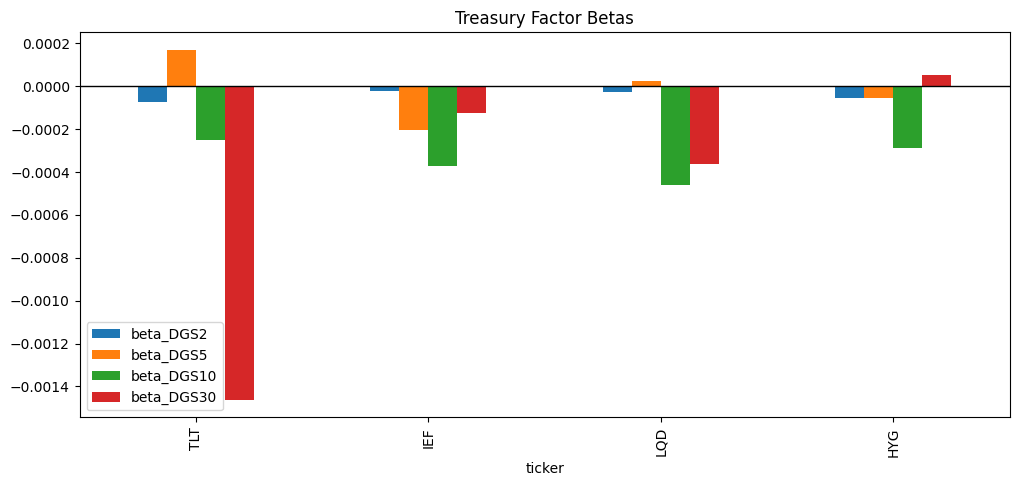

In [11]:
betas[["beta_DGS2", "beta_DGS5", "beta_DGS10", "beta_DGS30"]].plot(kind="bar", figsize=(12, 5), title="Treasury Factor Betas")
plt.axhline(0, color="black", linewidth=1)
plt.show()

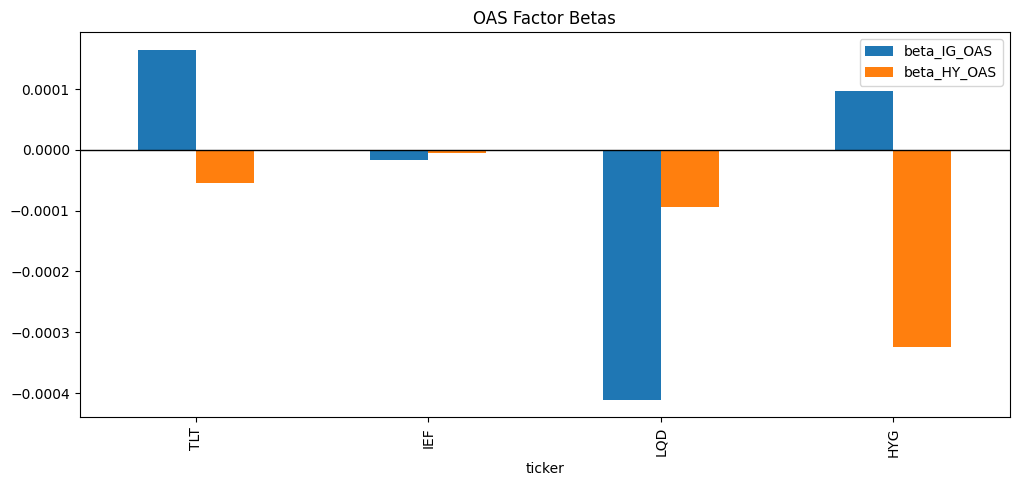

In [12]:
betas[["beta_IG_OAS", "beta_HY_OAS"]].plot(kind="bar", figsize=(12, 5), title="OAS Factor Betas")
plt.axhline(0, color="black", linewidth=1)
plt.show()

In [13]:
betas[["r2"]].sort_values("r2", ascending=False)

,r2
ticker,
TLT,0.943790
IEF,0.932398
LQD,0.814429
HYG,0.516688
